In [ ]:
!pip install lpips torch torchvision

In [1]:
image1_path = "output_canvas_optimized.png"
image2_path = "test-images/pride.png"

In [2]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

def compute_image_similarity(image_path1, image_path2):
    # Read the images
    img1 = cv2.imread(image_path1)
    img2 = cv2.imread(image_path2)

    # Ensure the images are the same size
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convert images to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Compute SSIM between the two images
    similarity_score, _ = ssim(gray1, gray2, full=True)

    return similarity_score

# Example usage
similarity = compute_image_similarity(image1_path, image2_path)
print(f"Similarity score: {similarity}")

Similarity score: 0.27330378492095175


In [3]:
import cv2
import numpy as np

def compute_image_similarity_mse(image_path1, image_path2):
    # Read and resize images
    img1 = cv2.imread(image_path1)
    img2 = cv2.imread(image_path2)
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Compute MSE
    mse = np.mean((gray1 - gray2) ** 2)
    return mse

# Example usage
mse_score = compute_image_similarity_mse(image1_path, image2_path)
print(f"MSE score: {mse_score}")


MSE score: 9602.4375


In [4]:
import cv2
import torch
import lpips
import numpy as np

def compute_image_similarity_lpips(image_path1, image_path2, net='alex'):
    # Load LPIPS model (AlexNet by default)
    loss_fn = lpips.LPIPS(net=net)

    # Read and resize images
    img1 = cv2.imread(image_path1)
    img2 = cv2.imread(image_path2)
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convert from BGR to RGB, scale to [0,1]
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) / 255.0
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) / 255.0

    # Convert to torch tensor and normalize to [-1, 1]
    def preprocess(img):
        tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
        return (tensor * 2) - 1  # scale to [-1, 1]

    t1 = preprocess(img1)
    t2 = preprocess(img2)

    # Compute LPIPS distance
    with torch.no_grad():
        distance = loss_fn(t1, t2).item()
    return distance

# Example usage
lpips_score = compute_image_similarity_lpips(image1_path, image2_path)
print(f"LPIPS perceptual distance: {lpips_score}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\alex.pth


C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

LPIPS perceptual distance: 0.9588077068328857


In [5]:
import cv2
import numpy as np
import torch
import lpips
import time
from skimage.metrics import structural_similarity as ssim

# ---- CONFIGURATION ----
image_path1 = "image1.jpg"  # Replace with your image path
image_path2 = "image2.jpg"  # Replace with your image path

# ---- LOAD IMAGES ----
def load_and_resize_images(path1, path2):
    img1 = cv2.imread(path1)
    img2 = cv2.imread(path2)
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    return img1, img2

# ---- MSE ----
def compute_mse(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY).astype(np.float32)
    return np.mean((gray1 - gray2) ** 2)

# ---- SSIM ----
def compute_ssim(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    score, _ = ssim(gray1, gray2, full=True)
    return score

# ---- LPIPS ----
def compute_lpips(img1, img2, net='alex'):
    loss_fn = lpips.LPIPS(net=net)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) / 255.0
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) / 255.0

    def preprocess(img):
        tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
        return (tensor * 2) - 1  # Scale to [-1, 1]

    t1 = preprocess(img1)
    t2 = preprocess(img2)

    with torch.no_grad():
        distance = loss_fn(t1, t2).item()
    return distance

# ---- RUN COMPARISON ----
img1 = cv2.imread(image1_path)
img2 = cv2.imread(image2_path)
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

results = {}

start = time.time()
mse = compute_mse(img1, img2)
results["MSE"] = (mse, time.time() - start)

start = time.time()
ssim_score = compute_ssim(img1, img2)
results["SSIM"] = (ssim_score, time.time() - start)

start = time.time()
lpips_score = compute_lpips(img1, img2)
results["LPIPS"] = (lpips_score, time.time() - start)

# ---- DISPLAY RESULTS ----
print("\n📊 Image Similarity Comparison\n")
for metric, (score, duration) in results.items():
    print(f"{metric:5s}: Score = {score:.5f} | Time = {duration:.4f} sec")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\alex.pth

📊 Image Similarity Comparison

MSE  : Score = 9602.43750 | Time = 0.0425 sec
SSIM : Score = 0.27330 | Time = 0.6156 sec
LPIPS: Score = 0.95881 | Time = 3.2111 sec


In [7]:
import cv2
import numpy as np
from PIL import Image
import random
import os
import json
import torch
import torchvision.transforms as transforms
import lpips


# Initialize LPIPS model (use VGG backbone)
lpips_loss_fn = lpips.LPIPS(net='vgg')
if torch.cuda.is_available():
    lpips_loss_fn.cuda()


def compute_image_similarity_lpips(pil_img1, pil_img2, loss_fn=lpips_loss_fn):
    transform = transforms.Compose([
        transforms.Resize((pil_img1.height, pil_img1.width)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img1_tensor = transform(pil_img1).unsqueeze(0)
    img2_tensor = transform(pil_img2).unsqueeze(0)

    if torch.cuda.is_available():
        img1_tensor = img1_tensor.cuda()
        img2_tensor = img2_tensor.cuda()

    with torch.no_grad():
        dist = loss_fn.forward(img1_tensor, img2_tensor)

    return -dist.item()  # Negate: lower LPIPS = better match → higher score


def calculate_coverage_percent(canvas):
    alpha_channel = np.array(canvas.split()[-1])  # extract alpha channel
    non_transparent_pixels = np.count_nonzero(alpha_channel)
    total_pixels = alpha_channel.size
    coverage = (non_transparent_pixels / total_pixels) * 100
    return coverage


def create_canvas_with_optimized_placement(image_folder, image_real_width, image_real_height, 
                                           canvas_real_width, canvas_real_height, comparison_image_path,
                                           num_images=10, num_placements=10, dpi=300,
                                           lpips_weight=1.0, coverage_weight=0.5):
    # Create the canvas
    canvas_width = int(canvas_real_width * dpi)
    canvas_height = int(canvas_real_height * dpi)
    canvas = Image.new('RGBA', (canvas_width, canvas_height), color=(255, 255, 255, 0))

    # Load and resize comparison image
    comparison_image = Image.open(comparison_image_path).convert('RGB')
    comparison_image = comparison_image.resize((canvas_width, canvas_height), Image.LANCZOS)

    # Get image list
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not image_files:
        print("No image files found.")
        return canvas

    # Load first image to get size
    first_image = Image.open(os.path.join(image_folder, image_files[0])).convert('RGBA')
    scale_x = (image_real_width * dpi) / first_image.width
    scale_y = (image_real_height * dpi) / first_image.height
    scale = min(scale_x, scale_y)
    new_width = int(first_image.width * scale)
    new_height = int(first_image.height * scale)

    placements = []  # Store metadata for each placed can

    for i in range(num_images):
        best_score = -np.inf
        best_canvas = None
        best_metrics = None
        best_metadata = None

        for _ in range(num_placements):
            temp_canvas = canvas.copy()

            # Random can
            img_filename = random.choice(image_files)
            img_path = os.path.join(image_folder, img_filename)
            img = Image.open(img_path).convert('RGBA').resize((new_width, new_height), Image.LANCZOS)
            rotation_angle = random.uniform(0, 360)
            img_rotated = img.rotate(rotation_angle, expand=True, resample=Image.BICUBIC)

            # Bounding box + random paste position
            bbox = img_rotated.getbbox()
            rotated_width = bbox[2] - bbox[0]
            rotated_height = bbox[3] - bbox[1]
            max_x = canvas_width - rotated_width
            max_y = canvas_height - rotated_height
            paste_x = random.randint(0, max(0, max_x))
            paste_y = random.randint(0, max(0, max_y))

            # Paste can onto canvas
            temp_canvas.paste(img_rotated, (paste_x, paste_y), img_rotated)

            # Compute similarity + coverage
            lpips_score = compute_image_similarity_lpips(temp_canvas.convert("RGB"), comparison_image)
            coverage_score = calculate_coverage_percent(temp_canvas)

            # Weighted score
            combined_score = (lpips_weight * lpips_score) + (coverage_weight * coverage_score)

            if combined_score > best_score:
                best_score = combined_score
                best_canvas = temp_canvas
                best_metrics = (lpips_score, coverage_score)
                best_metadata = {
                    "step": i + 1,
                    "filename": img_filename,
                    "translation": [paste_x, paste_y],
                    "rotation": rotation_angle,
                    "lpips_score": float(lpips_score),
                    "coverage": float(coverage_score)
                }

        # Finalize best placement for this step
        canvas = best_canvas
        placements.append(best_metadata)

        print(f"Image {i+1}/{num_images}: LPIPS = {-best_metrics[0]:.4f}, Coverage = {best_metrics[1]:.2f}%, Combined Score = {best_score:.2f}")
        # canvas.save(f"temp/output_canvas_step_{i+1}.png", format="PNG")

    # Save all placement data to JSON
    with open("placement_data.json", "w") as f:
        json.dump(placements, f, indent=2)

    return canvas


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Eoin/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:45<00:00, 12.1MB/s] 


Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\vgg.pth


In [9]:
image_folder = "test-cans/8.16x4.83"  # Replace with your folder path
image_real_width = 8.16  # inches
image_real_height = 4.83  # inches
canvas_real_width = 50  # inches
canvas_real_height = 61  # inches
comparison_image_path = "test-images/mac.png"  # Path to the comparison image
num_images = 100  # Number of images to paste
num_placements = 10  # Number of random placements to try for each image
dpi = 10
lpips_weight=1.0
coverage_weight=1.0

canvas = create_canvas_with_optimized_placement(image_folder, image_real_width, image_real_height, 
                                                canvas_real_width, canvas_real_height, comparison_image_path,
                                                num_images, num_placements,dpi, lpips_weight, coverage_weight)
canvas.save("output_canvas_optimized.png", format="PNG")
print("Canvas created with optimized image placement and saved as output_canvas_optimized.png")

Image 1/100: LPIPS = 0.8152, Coverage = 0.86%, Combined Score = 0.04
Image 2/100: LPIPS = 0.8162, Coverage = 1.71%, Combined Score = 0.89
Image 3/100: LPIPS = 0.8167, Coverage = 2.56%, Combined Score = 1.74
Image 4/100: LPIPS = 0.8160, Coverage = 3.41%, Combined Score = 2.59
Image 5/100: LPIPS = 0.8157, Coverage = 4.26%, Combined Score = 3.44
Image 6/100: LPIPS = 0.8166, Coverage = 5.12%, Combined Score = 4.30
Image 7/100: LPIPS = 0.8168, Coverage = 5.97%, Combined Score = 5.15
Image 8/100: LPIPS = 0.8187, Coverage = 6.82%, Combined Score = 6.01
Image 9/100: LPIPS = 0.8185, Coverage = 7.67%, Combined Score = 6.86
Image 10/100: LPIPS = 0.8177, Coverage = 8.52%, Combined Score = 7.71
Image 11/100: LPIPS = 0.8167, Coverage = 9.37%, Combined Score = 8.56
Image 12/100: LPIPS = 0.8176, Coverage = 10.23%, Combined Score = 9.41
Image 13/100: LPIPS = 0.8181, Coverage = 11.08%, Combined Score = 10.26
Image 14/100: LPIPS = 0.8166, Coverage = 11.93%, Combined Score = 11.11
Image 15/100: LPIPS = 0.

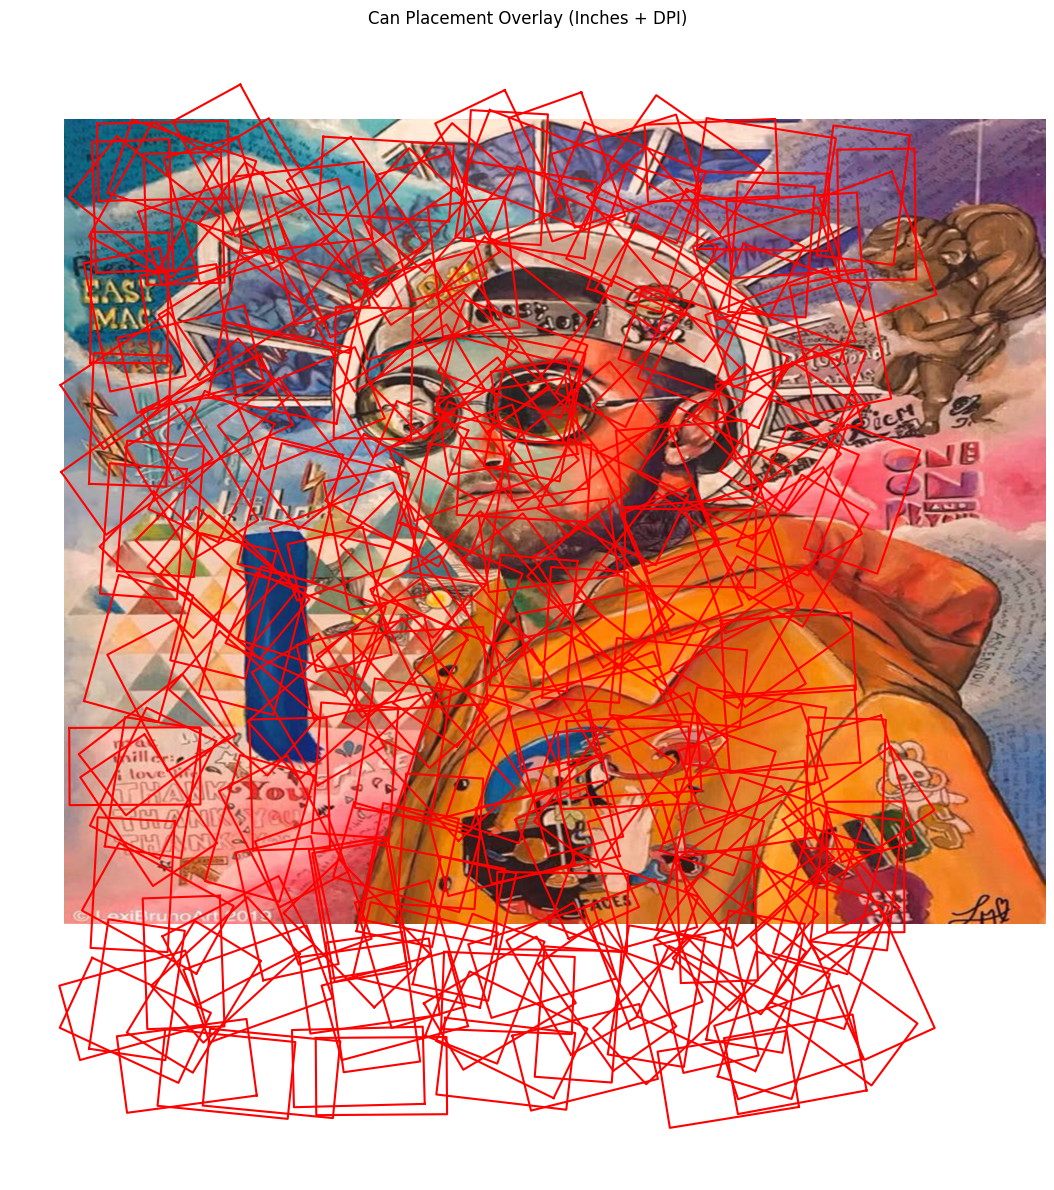

In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# --- CONFIGURATION ---
json_path = "placement_data.json"
comparison_image_path = "test-images/mac.png"  # Update path if needed

# Real-world sizes (in inches)
image_real_width = 8.16  # inches
image_real_height = 4.83  # inches
canvas_real_width = 61  # inches
canvas_real_height = 50  # inches
dpi = 30

# --- Derived pixel sizes ---
canvas_width = int(canvas_real_width * dpi)
canvas_height = int(canvas_real_height * dpi)
w_px = int(image_real_width * dpi)
h_px = int(image_real_height * dpi)

# --- Load data ---
with open(json_path, "r") as f:
    placements = json.load(f)

comparison_image = Image.open(comparison_image_path).convert("RGB")
comparison_image = comparison_image.resize((canvas_width, canvas_height), Image.LANCZOS)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(comparison_image)

for place in placements:
    x, y = place["translation"]
    theta = np.radians(place["rotation"])

    # Create rectangle corners centered at (0,0)
    hw, hh = w_px / 2, h_px / 2
    corners = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
        [-hw, -hh]  # close the rectangle
    ])

    # Rotate and translate
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    rotated = corners @ R.T + np.array([x + hw, y + hh])
    ax.plot(rotated[:, 0], rotated[:, 1], color='red', linewidth=1.5)

ax.set_title("Can Placement Overlay (Inches + DPI)")
ax.axis("off")
plt.tight_layout()
plt.show()
